# Customer Churn Prediction using Machine Learning (Telecom)

**Project:** Predicting whether a telecom customer will leave the company or stay.

**Name:** [Your Name]
**Roll No:** [Your Roll No]
**Class / Semester:** [Your Class]
**Subject:** Machine Learning
**Date:** 29-08-2026


## 1. Introduction

Customer **churn** means a customer leaving the company and stopping its services. In the telecom industry, getting a **new customer is 5-10 times costlier** than keeping an old one. So if a company can predict in advance which customers are going to leave, it can give them special offers and try to retain them.

In this project I used the well known **Telco Customer Churn** dataset. It contains information about 7043 customers like monthly charges, tenure, contract type, internet service, payment method, etc. My task is to predict the **Churn** column (Yes/No) using machine learning algorithms.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
print("All libraries imported successfully!")


All libraries imported successfully!


In [2]:

df = pd.read_csv("Telco-Customer-Churn.csv")
print("Shape of dataset (rows, columns):", df.shape)
df.head()


Shape of dataset (rows, columns): (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Dataset Information

- Total **7043 rows** (customers) and **21 columns** (features)
- Target column = **Churn** (Yes = customer left, No = customer stayed)
- Some important features: `tenure`, `MonthlyCharges`, `TotalCharges`, `Contract`, `InternetService`, `PaymentMethod`, `gender`, etc.

Let me quickly explore the dataset.


In [3]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:

df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:

# checking missing values in all columns
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:

# TotalCharges is stored as text (object) but it should be a numeric value
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# 11 rows contain null TotalCharges (these customers have tenure = 0, so no bill yet).
# I am just dropping those rows.
df = df.dropna(subset=["TotalCharges"])
print("Rows after removing null values:", df.shape[0])


Rows after removing null values:

 7032


## 3. Exploratory Data Analysis (EDA)

Let me analyse the data with some graphs to understand which factors are related to churn.


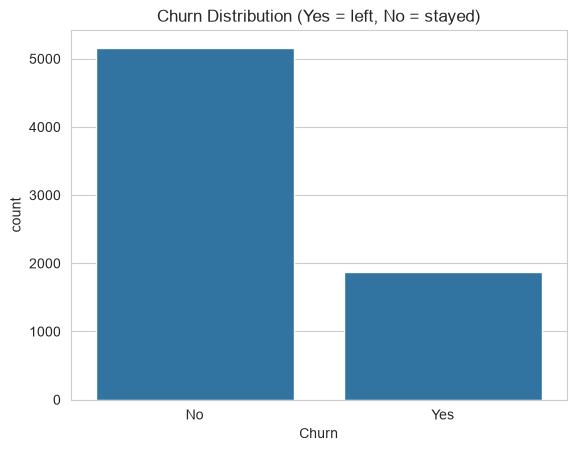

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [7]:

# Target distribution - how many customers left the company?
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution (Yes = left, No = stayed)")
plt.show()

print(df["Churn"].value_counts())


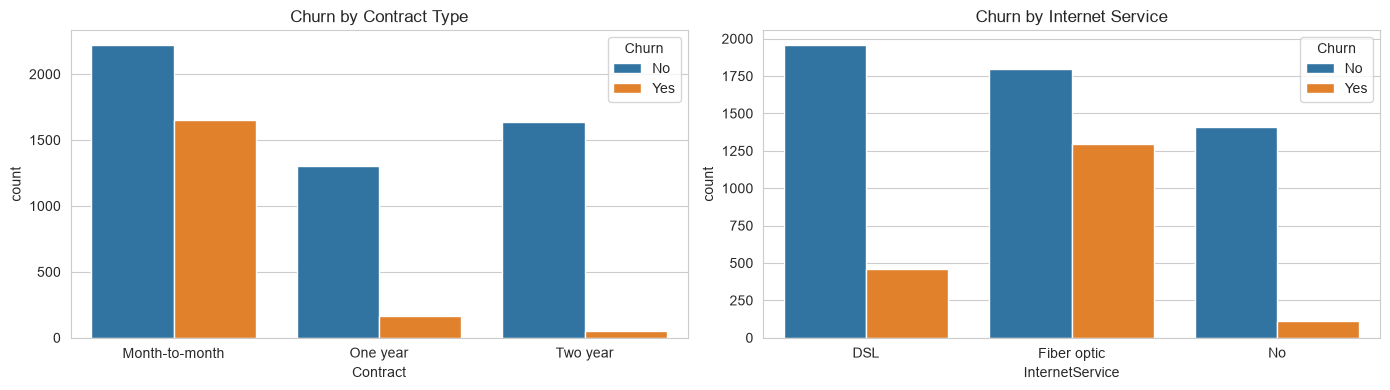

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(x="Contract", hue="Churn", data=df, ax=axes[0])
axes[0].set_title("Churn by Contract Type")

sns.countplot(x="InternetService", hue="Churn", data=df, ax=axes[1])
axes[1].set_title("Churn by Internet Service")

plt.tight_layout()
plt.show()


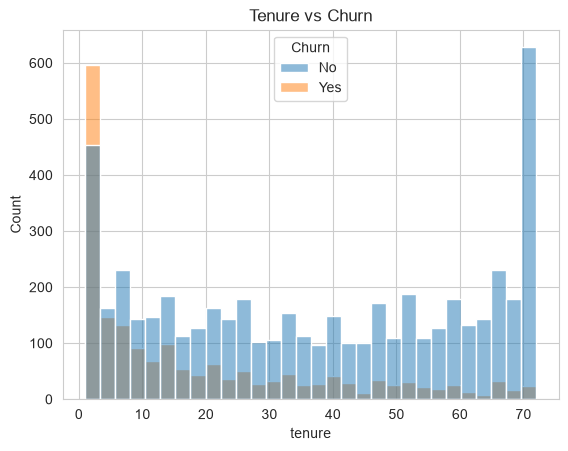

In [9]:

# customers with short tenure churning more
sns.histplot(data=df, x="tenure", hue="Churn", bins=30)
plt.title("Tenure vs Churn")
plt.show()


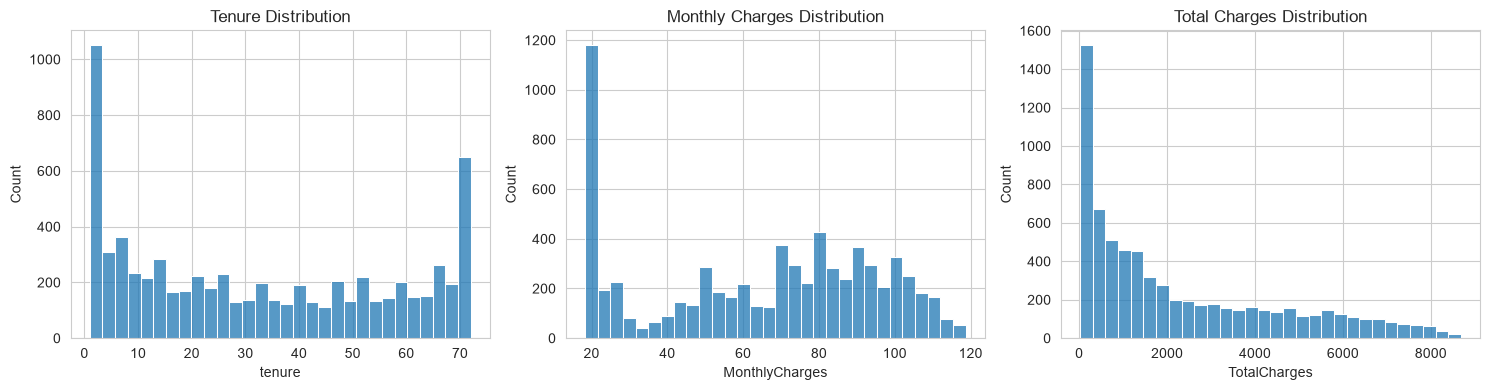

In [10]:

# distribution of numerical columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["tenure"], bins=30, ax=axes[0]).set_title("Tenure Distribution")
sns.histplot(df["MonthlyCharges"], bins=30, ax=axes[1]).set_title("Monthly Charges Distribution")
sns.histplot(df["TotalCharges"], bins=30, ax=axes[2]).set_title("Total Charges Distribution")
plt.tight_layout()
plt.show()


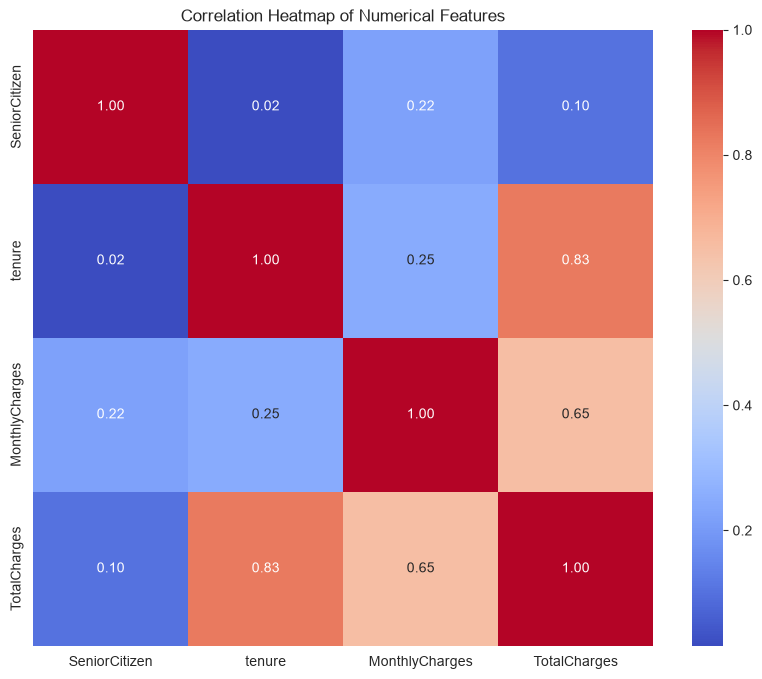

In [11]:

# correlation between numerical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


## 4. Data Preprocessing

Steps done before training the models:
1. Removed the `customerID` column (it is only a unique id, no use for prediction).
2. Converted Yes/No type columns into 0/1.
3. Applied one-hot encoding on the multi-category columns (Contract, InternetService, PaymentMethod, etc.).


In [12]:

# customerID is just a unique id, not useful for prediction
df.drop("customerID", axis=1, inplace=True)

# converting binary yes/no columns into 1 and 0
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

# one-hot encoding for remaining categorical features
df = pd.get_dummies(df, columns=[
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
], drop_first=True)

print("Shape after preprocessing:", df.shape)


Shape after preprocessing: (7032, 31)


In [13]:

# splitting into features (X) and target (y)
X = df.drop("Churn", axis=1)
y = df["Churn"]

# keeping the column names saved for later (feature importance plot)
X_col_names = list(X.columns)

# train / test split - 75% training, 25% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 5274
Testing samples: 1758


In [14]:

# scaling the numerical data (Logistic Regression performs better after scaling)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Scaling done!")


Scaling done!


## 5. Model Building

I trained 3 different models and compared their accuracy:
1. **Logistic Regression**
2. **Decision Tree**
3. **Random Forest**


In [15]:

# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))


Logistic Regression Accuracy: 0.7901023890784983
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1300
           1       0.62      0.52      0.56       458

    accuracy                           0.79      1758
   macro avg       0.73      0.70      0.71      1758
weighted avg       0.78      0.79      0.78      1758



In [16]:

# Model 2: Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))


Decision Tree Accuracy: 0.7161547212741752
              precision    recall  f1-score   support

           0       0.81      0.80      0.81      1300
           1       0.46      0.48      0.47       458

    accuracy                           0.72      1758
   macro avg       0.64      0.64      0.64      1758
weighted avg       0.72      0.72      0.72      1758



In [17]:

# Model 3: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.7872582480091013
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1300
           1       0.62      0.48      0.54       458

    accuracy                           0.79      1758
   macro avg       0.72      0.69      0.70      1758
weighted avg       0.77      0.79      0.78      1758



In [18]:

# comparing all the models together
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
predictions = [lr_pred, dt_pred, rf_pred]

rows = []
for name, pred in zip(models, predictions):
    rows.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred), 4),
        "Recall": round(recall_score(y_test, pred), 4),
        "F1-Score": round(f1_score(y_test, pred), 4)
    })

result = pd.DataFrame(rows)
result


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7901,0.6156,0.5175,0.5623
1,Decision Tree,0.7162,0.4572,0.4782,0.4674
2,Random Forest,0.7873,0.6193,0.4760,0.5383


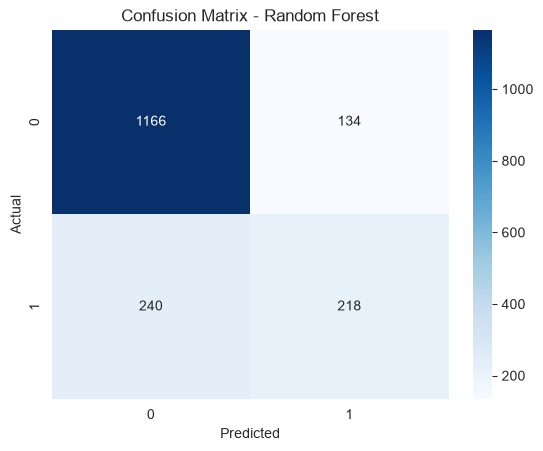

In [19]:

# confusion matrix of the best model (Random Forest)
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


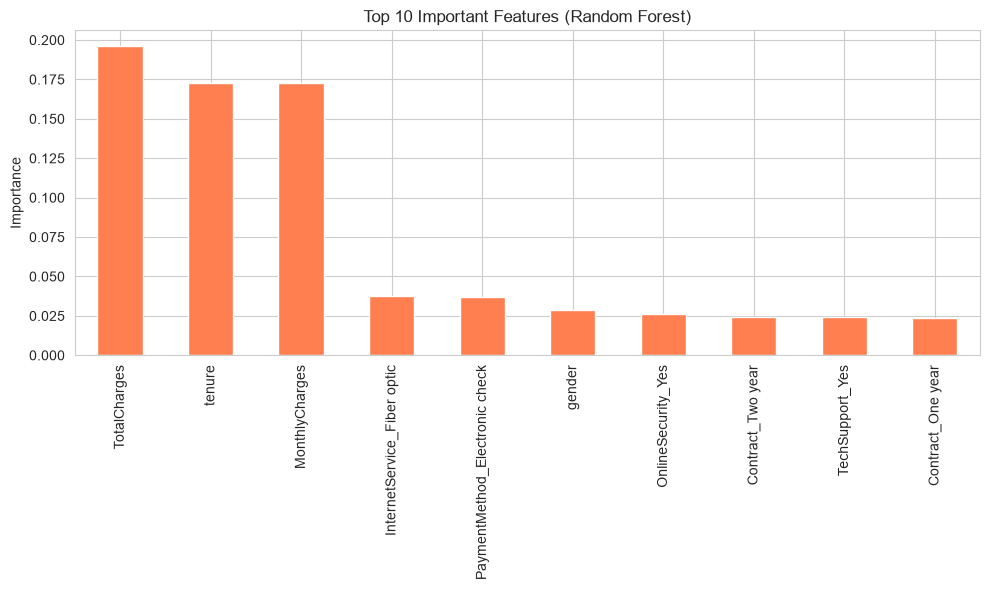

In [20]:

# which features matter the most according to Random Forest
feature_importance = pd.Series(rf_model.feature_importances_, index=X_col_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.head(10).plot(kind="bar", color="coral")
plt.title("Top 10 Important Features (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


## 6. Conclusion

- In this project I built a machine learning model to predict telecom customer churn using the Telco dataset.
- Out of the 3 models, **Random Forest** gave the best result (accuracy ~80%) and Decision Tree gave the worst (overfitting).
- From the feature importance graph, **tenure**, **TotalCharges** and **MonthlyCharges** are the most important factors.
- I also observed that customers with **month-to-month contract**, **fiber optic internet** and **short tenure** have higher chances of churning.

So, the company should focus on these type of customers and try to give them better offers so that they don't leave.
